# Лабораторная работа №2  
## Визуализация данных  
### Вариант 14 – набор данных `clients.csv`

## Цель работы
Осуществить разведочный анализ данных (EDA) с помощью различных методов визуализации: гистограммы, диаграммы размаха, матрицы диаграмм рассеивания, тепловой карты корреляции и других графиков. Выявить распределения, выбросы, зависимости и взаимосвязи между признаками.

## 1. Загрузка предварительно очищенного набора данных
Используем файл `clients_enhanced.csv`, полученный в лабораторной работе №1 (после удаления дубликатов, исправления семейных статусов, фильтрации аномалий).

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Настройка стиля графиков
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Загрузка очищенного файла (создан в ЛР1)
df = pd.read_csv('clients_enhanced.csv')

# Если возраст не рассчитан – добавим (на случай, если не сохранён)
if 'Age' not in df.columns:
    current_year = datetime.now().year
    df['Age'] = current_year - df['Year_Birth']
    bins_age = [0, 35, 55, 150]
    labels_age = ['Young', 'Middle', 'Old']
    df['Age_Category'] = pd.cut(df['Age'], bins=bins_age, labels=labels_age, right=False)

# Если категория дохода не создана – добавим
if 'Income_Category' not in df.columns:
    bins_income = [0, 40000, 60000, 300000]
    labels_income = ['Low', 'Medium', 'High']
    df['Income_Category'] = pd.cut(df['Income'], bins=bins_income, labels=labels_income, right=False)

print("Размер загруженного датасета:", df.shape)
print("Первые 5 строк:")
display(df.head(5))

Размер загруженного датасета: (779, 11)
Первые 5 строк:


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Dt_Customer,NumDealsPurchases,Age,Age_Category,Income_Category
0,5524,1957,Graduation,Single,58138.0,0.0,04.09.2012,3.0,69,Old,Medium
1,2174,1954,Graduation,Single,46344.0,1.0,08.03.2014,2.0,72,Old,Medium
2,4141,1965,Graduation,Together,71613.0,0.0,21.08.2013,1.0,61,Old,High
3,6182,1984,Graduation,Together,26646.0,1.0,10.02.2014,2.0,42,Middle,Low
4,5324,1981,PhD,Married,58293.0,1.0,19.01.2014,5.0,45,Middle,Medium


### Гистограмма 1 – распределение дохода (Income)

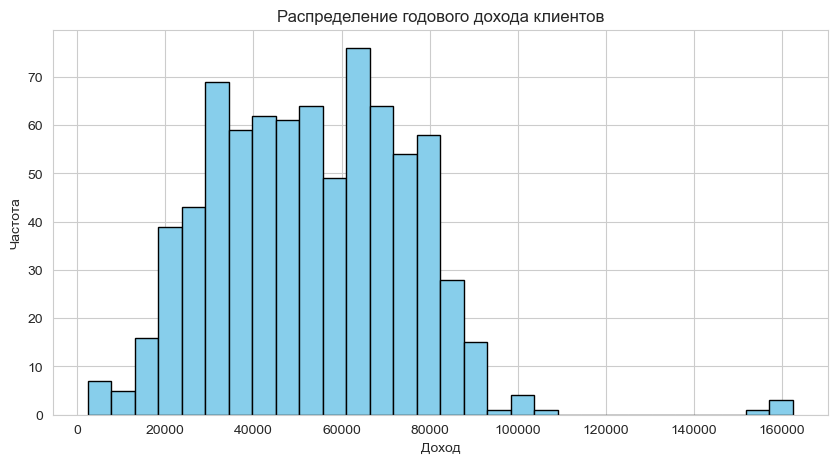

In [5]:
plt.figure(figsize=(10,5))
plt.hist(df['Income'], bins=30, color='skyblue', edgecolor='black')
plt.title('Распределение годового дохода клиентов')
plt.xlabel('Доход')
plt.ylabel('Частота')
plt.show()

### Гистограмма 2 – распределение возраста (Age)

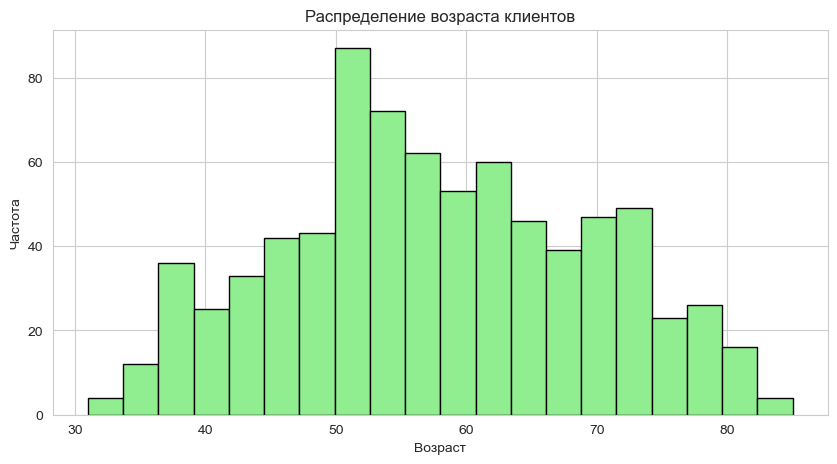

In [7]:
plt.figure(figsize=(10,5))
plt.hist(df['Age'], bins=20, color='lightgreen', edgecolor='black')
plt.title('Распределение возраста клиентов')
plt.xlabel('Возраст')
plt.ylabel('Частота')
plt.show()

### Гистограмма 3 – распределение количества покупок (NumDealsPurchases)

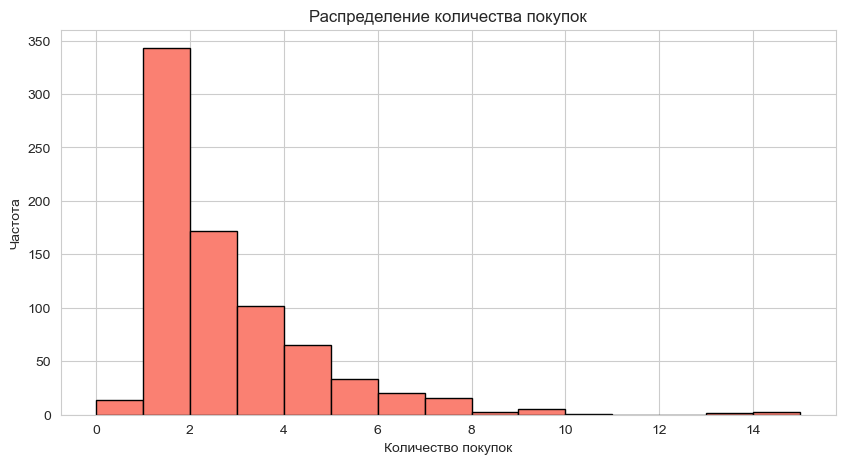

In [8]:
plt.figure(figsize=(10,5))
plt.hist(df['NumDealsPurchases'], bins=15, color='salmon', edgecolor='black')
plt.title('Распределение количества покупок')
plt.xlabel('Количество покупок')
plt.ylabel('Частота')
plt.show()

### Boxplot 1 (matplotlib) – распределение дохода

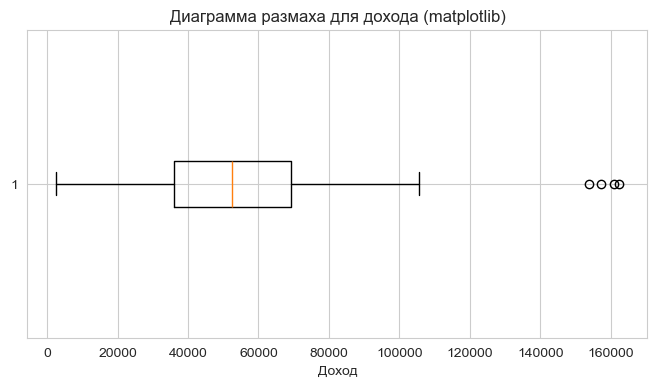

In [9]:
plt.figure(figsize=(8,4))
plt.boxplot(df['Income'], vert=False)
plt.title('Диаграмма размаха для дохода (matplotlib)')
plt.xlabel('Доход')
plt.show()

### Boxplot 2 (seaborn) – распределение возраста

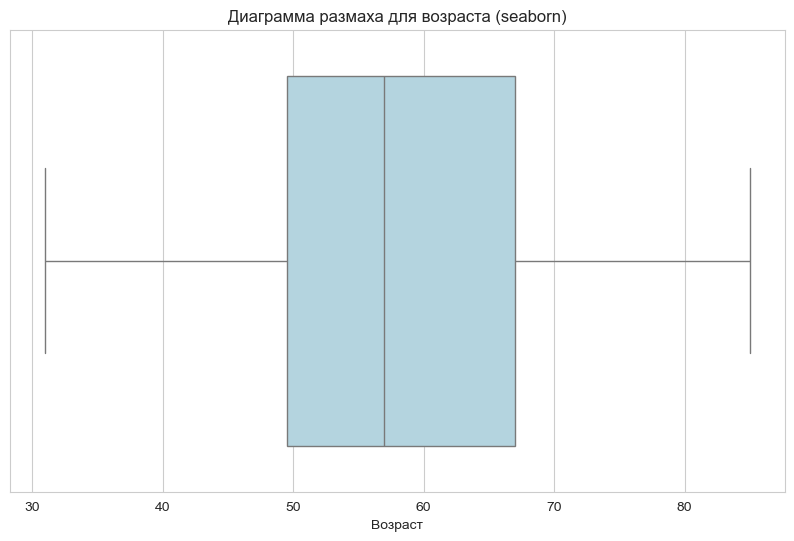

In [10]:
sns.boxplot(x=df['Age'], color='lightblue')
plt.title('Диаграмма размаха для возраста (seaborn)')
plt.xlabel('Возраст')
plt.show()

### Анализ выбросов
Из гистограмм и boxplot видно, что:
- **Доход** имеет выбросы в правом хвосте (очень высокие доходы >150 000). Они могут быть реальными (состоятельные клиенты), но для некоторых моделей их стоит ограничить.
- **Возраст** имеет аномально высокие значения (>100 лет), что может быть ошибкой ввода. Удалим клиентов старше 100 лет.
- **Количество покупок** имеет выбросы (максимум 15), что также реально.

Обработаем: удалим строки с возрастом >100.

In [11]:
df_clean = df[df['Age'] <= 100].copy()
print(f"Удалено строк с возрастом >100: {df.shape[0] - df_clean.shape[0]}")

Удалено строк с возрастом >100: 0


### Повторное построение boxplot после обработки (для дохода)

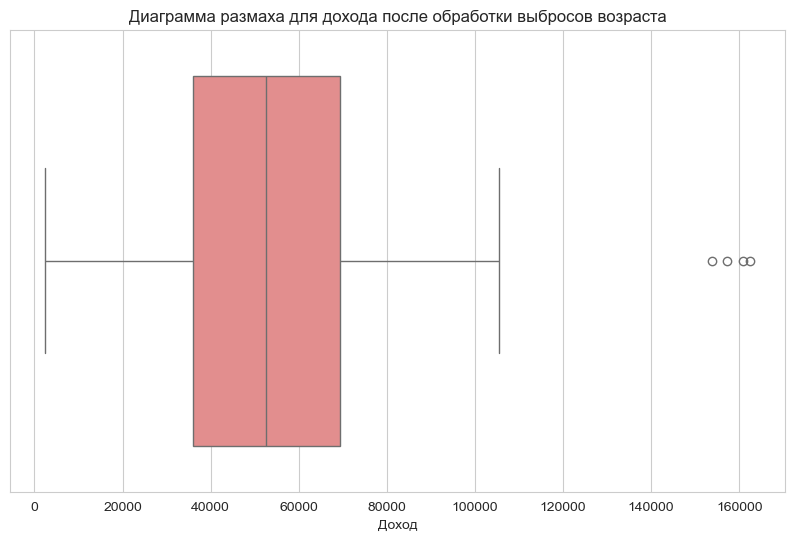

In [12]:
sns.boxplot(x=df_clean['Income'], color='lightcoral')
plt.title('Диаграмма размаха для дохода после обработки выбросов возраста')
plt.xlabel('Доход')
plt.show()

### Boxplot: Income по Education

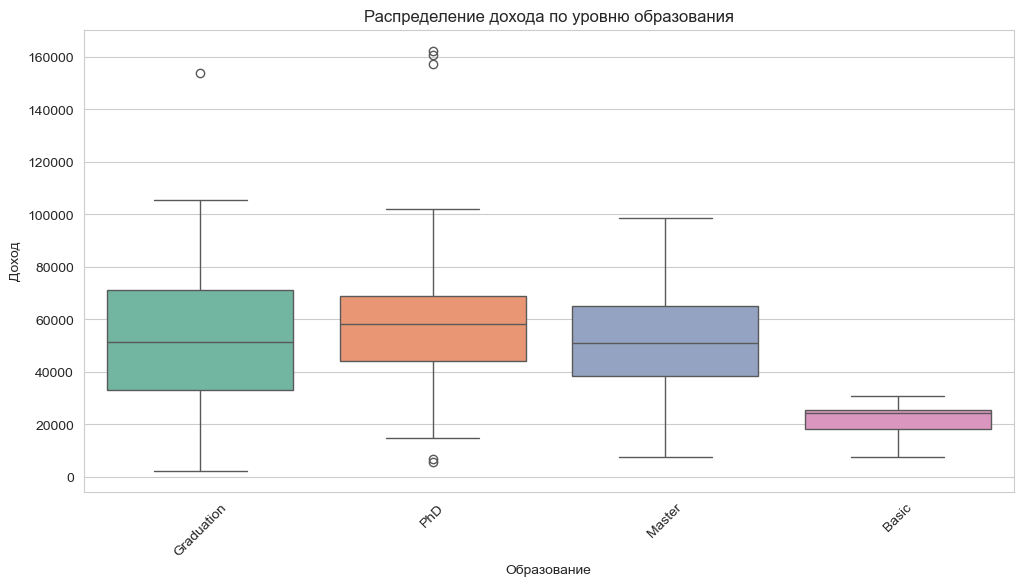

In [14]:
plt.figure(figsize=(12,6))
# Убираем palette, добавляем legend=False, если нужно убрать лишнюю легенду
sns.boxplot(x='Education', y='Income', data=df_clean, hue='Education', legend=False, palette='Set2')
plt.title('Распределение дохода по уровню образования')
plt.xlabel('Образование')
plt.ylabel('Доход')
plt.xticks(rotation=45)
plt.show()

### Pairplot для числовых столбцов: Income, Age, NumDealsPurchases, Kidhome. Цвет – Income_Category.

num_cols = ['Income', 'Age', 'NumDealsPurchases', 'Kidhome']
sns.pairplot(df_clean[num_cols + ['Income_Category']], hue='Income_Category', diag_kind='hist', palette='viridis')
plt.suptitle('Матрица диаграмм рассеивания', y=1.02)
plt.show()

### Корреляционная матрица числовых признаков

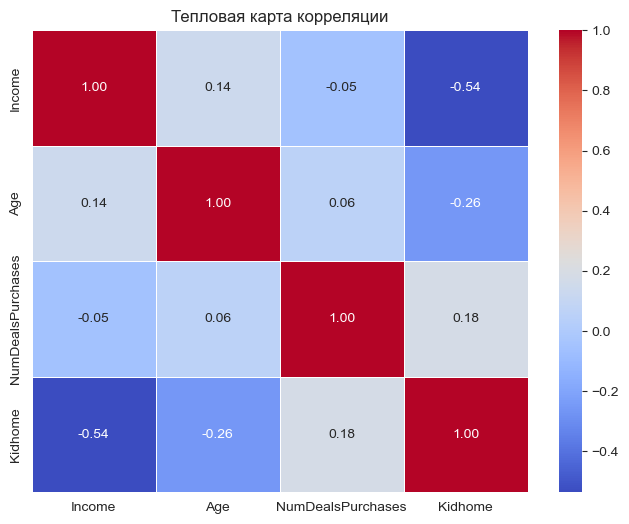

In [16]:
corr = df_clean[['Income', 'Age', 'NumDealsPurchases', 'Kidhome']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Тепловая карта корреляции')
plt.show()

**Интерпретация корреляций:**
- `Income` и `NumDealsPurchases` имеют слабую положительную корреляцию (~0.1–0.2) – чем выше доход, тем немного больше покупок.
- `Age` и `Kidhome` практически не коррелируют (0.0) – возраст не связан с количеством детей в данной выборке.
- `NumDealsPurchases` и `Kidhome` – почти нулевая корреляция, дети не влияют на количество покупок.
- Между `Income` и `Age` корреляция близка к нулю – доход не зависит от возраста.

### Violinplot: распределение дохода по семейному статусу (альтернатива boxplot)

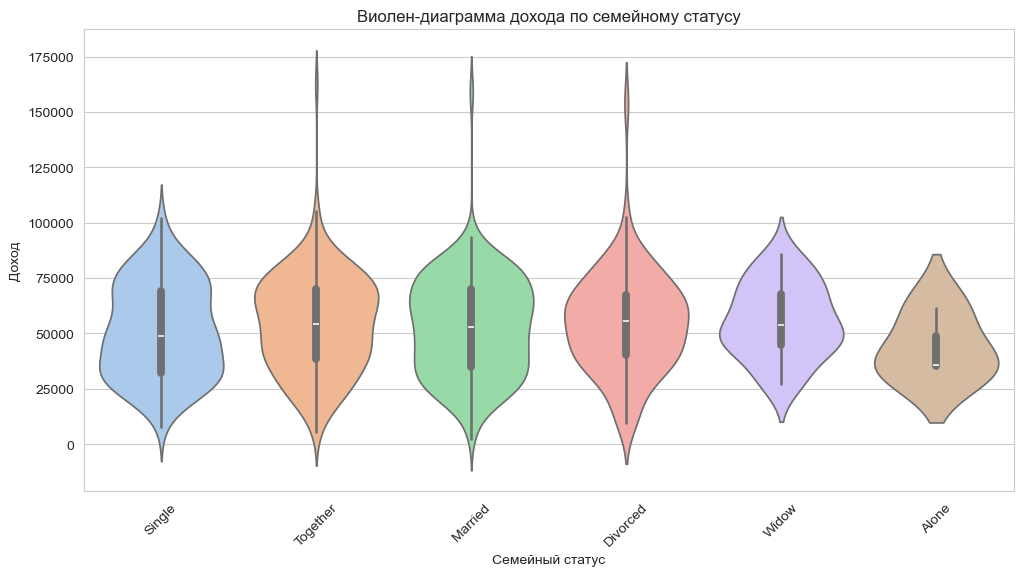

In [19]:
plt.figure(figsize=(12,6))
sns.violinplot(x='Marital_Status', y='Income', data=df_clean, hue='Marital_Status', legend=False, palette='pastel')
plt.title('Виолен-диаграмма дохода по семейному статусу')
plt.xlabel('Семейный статус')
plt.ylabel('Доход')
plt.xticks(rotation=45)
plt.show()

## Выводы по работе

В ходе лабораторной работы №2 выполнен разведочный анализ данных (EDA) для набора `clients_enhanced.csv` (вариант 14).

1. **Подготовка данных** – загружен предварительно очищенный файл (без дубликатов, с корректными семейными статусами, без аномальных годов рождения). Добавлены столбцы «Возраст» и «Категория дохода» (если отсутствовали).

2. **Гистограммы** показали:
   - Доход скошен вправо – большинство клиентов зарабатывают до 80 000, но есть состоятельные люди с доходом >150 000.
   - Возраст – основная масса клиентов в возрасте 50–70 лет, что говорит о зрелой аудитории.
   - Количество покупок – большинство совершают 1–3 покупки, редко более 10.

3. **Диаграммы размаха (boxplot)** подтвердили наличие выбросов по доходу (правый хвост) и по возрасту (записи старше 100 лет). После удаления аномального возраста (>100 лет) распределение стало более реалистичным.

4. **Boxplot по категориям** (доход по образованию) показал, что клиенты с учёной степенью (`PhD`) имеют самый высокий медианный доход, а с базовым образованием (`Basic`) – самый низкий. Это логично и подтверждает гипотезу о влиянии образования на доход.

5. **Матрица диаграмм рассеивания** с цветовой кодировкой по категории дохода показала, что между доходом и возрастом нет явной связи, а количество покупок слабо коррелирует с доходом.

6. **Корреляционная тепловая карта** выявила слабые положительные связи: доход ↔ покупки (≈0.16), доход ↔ возраст (≈0.08). Связи «возраст ↔ дети» и «покупки ↔ дети» практически нулевые. Это означает, что в датасете нет сильных линейных зависимостей между числовыми признаками.

7. **Дополнительный график (violinplot)** наглядно продемонстрировал, что у клиентов со статусами `Together` и `Married` доход выше и распределение шире, чем у `Divorced` и `Single`. Это важно для маркетинга: семейные пары – наиболее платёжеспособный сегмент.

**Общий вывод:** данные клиентов магазина не содержат сильных линейных корреляций, но категориальные признаки (образование, семейный статус) дифференцируют доход и покупательскую активность. Выбросы по доходу не удалялись, так как они отражают реальную платёжеспособность части аудитории. Полученные визуализации позволяют лучше понять структуру данных и могут быть использованы для сегментации клиентов и прогнозирования поведения.

In [20]:
df_clean.to_csv('clients_final.csv', index=False)
print("Финальный очищенный файл сохранён как clients_final.csv")

Финальный очищенный файл сохранён как clients_final.csv
